# Introduction

In this tutorial, we solve several example problems and explain the main concepts behind the use of the `distributed` module.

**Notation:**

Let $\mathcal{D} \subset \mathbb{R}^d$ be an open bounded domain, with boundary
$\Gamma = \partial \mathcal{D}$. Let $n$ denote the unit normal vector to $\Gamma$.
Given a set $\Omega \subset \mathcal{D}$, $\chi_{\Omega}$ denote
the indicator function of $\Omega$:
$$
\chi_\Omega(x) = 
\begin{cases}
1 & \text{if } x \in \Omega, \\
0 & \text{if } x \notin \Omega.
\end{cases}
$$
Let $I\in\mathbb{R}^{d\times d}$ denote the $d$-dimensional identity matrix.
Given a vector-valued function $w(x)=(w_1(x), \ldots, w_d(x))$, $Dw$ denotes its Jacobian matrix:
$$
Dw(x) = (\nabla w_1 (x), \dots ,\nabla w_d(x))^\top,
$$
with the gradients $\nabla w_i (x)$ viewed as column vectors.
Finally, $H^1(\mathcal{D})$ and $H^1_0(\mathcal{D})$ are the usual Sobolev spaces.

**Comments about code.**
All the code is written in Python. Throughout this tutorial, the term *Array* always refers to a NumPy array. The problem equations are implemented as methods of a class that must inherit from the `Model` class. In general, it is recommended to be familiar with the principles of object-oriented programming.

# Compliance minimization

Here, we minimize the compliance in a linear elasticity problem.

Let $\Gamma_0$, $\Gamma_1$ be subsets of $\Gamma$.
The optimization problem reads:
$$
\min_{\Omega \subset \mathcal{D}} \int_{\mathcal{D}} A_{\Omega}\sigma(u):\epsilon(u)
\quad\text{subject to}\quad
\int_{\mathcal{D}} \chi_{\Omega} = V
$$
where $u$ is the solution to
$$
\begin{aligned}
    -\mathrm{div} A_{\Omega} \sigma(u)  & = 0 && \text{in} \quad \mathcal{D} \\
                                     u  & = 0 && \text{on} \quad \Gamma_{0} \\
                 A_{\Omega} \sigma(u)n  & = g && \text{on} \quad \Gamma_{1} \\
                 A_{\Omega} \sigma(u)n  & = 0 && \text{on} \quad \Gamma \backslash (\Gamma_{1} \cup \Gamma_{1})              
\end{aligned}
$$
with $A_{\Omega}:\overline{\mathcal{D}} \rightarrow \mathbb{R}$ defined by
$A_{\Omega} = \chi_{\Omega} + \kappa\chi_{\overline{\mathcal{D}}\backslash\Omega}$,
and the strain and stress tensors are given by
$$
\epsilon(w)=\frac{Dw+{Dw}^{\top}}{2}
\quad \text{and} \quad
\sigma(w)=2\mu\,\epsilon(w)+\lambda(\nabla\cdot w)I, 
$$
respectively. The constants $\mu$ and $\lambda$ are Lamé’s elasticity parameters,
$\kappa$ is a small positive number,
and $V$ is a fixed volume less than the volume of $\mathcal{D}$.

> **Remark:** Note that $A_\Omega$ is given by
> $$
> A_\Omega(x) = 
> \begin{cases}
> 1 & \text{if } x \in \Omega, \\
> \kappa & \text{if } x \notin \Omega.
> \end{cases}
> $$

## Symmetric cantilever

We start with the classical problem of minimizing the compliance for the symmetric cantilever in dimension $d=2$. The first step is to construct a model class with the parameters and equations of the problem. We have written the class `Compliance(Model)` with the following attributes and methods:

* Required attributes: `dim` (domain dimension), `domain` (problem domain), `space` (solution space), `path` (problem path). Every model class must define these attributes.

* Other attributes: `dx`, `ds`, `g`, `ds_g`, etc.

* Constructor of the class: `__init__`. It runs automatically when you create a new object from the class.

* Required methods: `pde`, `adjoint`, `cost`, `constraint`, `derivative`, `bilinear_form`.



In the constructor of the class are attributes that model
$\epsilon(w)$, $\sigma(w)$, $A_{\Omega}$, and $\chi_{\Omega}$ as Python *lambda* functions. For instance, the attribute

```python
self.A = lambda w: conditional(lt(w, 0.0), 1.0, 1e-4)
```

models $A_{\Omega} = \chi_{\Omega} + \kappa\chi_{\mathcal{D}\backslash\Omega}$ with $\kappa = {10}^{-4}$. Since the domain $\Omega$ is determined by the inverse image of the negative values of a level set function, we will use `self.A(phi)`, where `phi` models the level set function.

The method `pde(self, phi)` models the weak formulation of linear elasticity equations: Find $u \in  H^1_{\Gamma_0}(\mathcal{D})^d$ such that
$$
\int_{\mathcal{D}} A_{\Omega}\sigma(u):e(v) = \int_{\Gamma_1} g \cdot v
\qquad
\forall \, v \in  H^1_{\Gamma_0}(\mathcal{D})^d
$$
We must write the above weak formulation as $W(u,v)=0$ in the method `pde`:
```python
su = self.sigma(u)
ev = self.epsilon(v)
W = self.A(phi)*inner(su, ev)*self.dx - dot(self.g, v)*self.ds_g
```
The method `pde`returns a list of tuples, where each tuple represents a state problem. In this case, `pde` returns the list `[(W, self.bc)]`, where `self.bc` is the Dirichlet boundary condition.

The method `adjoint(self, phi, U)` is empty because this is a self-adjoint problem.

The method `cost(self, phi, U)` returns the cost function
$$
J(\Omega) = \int_{\mathcal{D}} A_{\Omega}\sigma(u):\epsilon(u)
$$
The argument `U` represents a list of state functions. Since in this case there is only one state, we use `U[0]` (element at position zero) as $u$:

```python
u = U[0]
su = self.sigma(u)
eu = self.epsilon(u)
J = self.A(phi)*(inner(su, eu))*self.dx
```

The method `constraint(self, phi, U)` models the volume constraint function
$$
C(\Omega) = \frac{1}{V} \int_{\mathcal{D}} \chi_{\Omega}
$$
Recall that the constraint is formulated in the form $C(\Omega)=\boldsymbol{1}$. The attribute

```python
self.chi = lambda w: conditional(lt(w, 0.0), 1.0, 0.0)
```
is used to model $\chi_{\Omega}$. The volume $V$ is also a attribute of the class. In the method `constraint` we write
```python
C = (1.0/self.vol)*self.chi(phi)*self.dx
```

The method `derivative(self, phi, U, P)` returns the components $S_0$ and $S_1$ of the distributed shape derivatives of the cost functional and the constraints. For the cost function $J$, theses components are
$$
S_0^J = \boldsymbol{0}, \quad
S_1^J = A_{\Omega} (2{Du}^{\top}\sigma(u)- \sigma(u):\epsilon(u))I.
$$
where $u$ is the solution to the weak formulation of the problem. In this case, there is only one constraint. Its derivative components are
$$
S_0^C = \boldsymbol{0}, \quad S_1^C = \frac{1}{V} \chi_{\Omega}I.
$$
These components are vector and tensor expressions. We write them as

```python
su = self.sigma(u)
eu = self.epsilon(u)
S0_J = self.zero_vec
S1_J = self.A(phi)*(2.0*grad(u).T*su - inner(su, eu)*self.Id)
S0_C = self.zero_vec
S1_C = (1.0/self.vol)*self.chi(phi)*self.Id
```
The method must return two lists containing the $S_0$ and $S_1$ components, respectively. 

The method `bilinear_form(self, th, xi)` contains the bilinear form to be used to calculate the vector field $\theta$. In this case,

$$
    B(\theta, \xi) =  {10}^{-1} \int_{\mathcal{D}} \theta \cdot \xi + 
        \int_{\mathcal{D}} D\theta : D\xi +
        {10}^4 \int_{\partial \mathcal{D}}  (\theta \cdot n) (\xi \cdot n)
$$

with $\theta, \xi \in H^1(\mathcal{D})^d$. To indicate that there is no Dirichlet boundary, the method must return the boolean `False` along with the bilinear form.

**Remark.** The class that models the problem and its equations must be written exclusively using UFL and native Python functions.

With the model class defined, the next step is to build the domain. Consider the rectangular domain $\Omega = (0, 2)\times(0, 1)$. We will apply one force on the subset of boundary determined by the line segment that is bounded by the points $(2, 0.45)$ and $(2, 0.55)$. The Dirichlet condition will be applied on the line segment that is bounded by the points $(0, 0)$ and $(0, 1)$. We use the function `create_domain_2d_DP` with the following arguments to create the domain (DP indicates Data Parallelism):

```python
vertices = np.array([
    (0.0, 0.0),
    (2.0, 0.0),
    (2.0, 0.45),
    (2.0, 0.55),
    (2.0, 1.0),
    (0.0, 1.0)
])
    
dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2
boundary_parts = [
    (dir_idx, dir_mkr, "dir"),
    (neu_idx, neu_mkr, "neu")
]
```

The array `vertices` contains the vertices of the boundary domain considering the line segments where we want to apply the Dirichlet and Neumann conditions. By convention, the vertices are written in counterclockwise direction. The list `boundary_parts` contains the segment numbers, marks, and names corresponding to the line segments where we will apply the Dirichlet and Neumann conditions. For instance, the list `dir_idx` contains the number `6`, because we want to apply the Dirichlet condition only on the sixth line segment (which have initial point `(0.0, 1.0)` and final point `(0.0, 0.0)`). The marks `dir_mkr` and `neu_mkr` are integers grater than `0` to identify the groups of segments.

Thus, we have the following correspondence:

* $\Gamma_0$ is represented by `(dir_idx, dir_mkr, "dir")`
* $\Gamma_1$ is represented by `(neu_idx, neu_mkr, "neu")`

Once the domain is in place, we can proceed to create a model for our test, that is, to instantiate an object of the class `Compliance`. The more important arguments are the following:

```python
# Space for the PDE solution
space = dib.create_space(domain, "CG", rank_dim)
# Dirichlet condition
dirichlet_bcs = dib.homogeneous_dirichlet(
    domain, space, boundary_tags,
    [dir_mkr], rank_dim
)
# Boundary to force application 
ds_g = dib.marked_ds(
    domain,
    boundary_tags,
    [neu_mkr]
)
```

The function `create_space` is just a wrapper of the function `functionspace` of `dolfinx.fem`.
It creates the finite element space for the weak solution.
The function `homogeneous_dirichlet` returns a list with the boundary condition marked with `dir_mkr`.
Note that it is necessary to pass as an argument the boundary tags of the domain.
The function `marked_ds` returns the `ds`-measure corresponding to the Neumann condition,
which will be used to build the weak form of the problem.
Now we create the model and set a constraint for the vector field:
```python
area = 1.0
g = (0.0, -2.0)

md = Compliance(
    dim, domain, space, g, ds_g[0],
    dirichlet_bcs, area, test_path
)

@dib.region_of(domain)
def sub_domain(x):
    # 0.42 < x[1] < 0.58
    # 1.95 < x[0]
    ineqs = [
        x[1] - 0.42,
        0.58 - x[1],
        x[0] - 1.95
    ]
    return ineqs

md.sub = [sub_domain.expression()]
```

The function `sub_domain` determines the set
$$
\Omega_0 = \left\{ (x,y)\in \mathcal{D} \mid 1.95 < x,\, 0.42 < y < 0.58   \right\}.
$$
We decorate `sub_domain` with `@region_of(domain)`,
which allows to call the method `expression()`.
This method transform the function `sub_domain` to an UFL expression.
With this, the model will add a term of the form
$$
{10}^5 \int_{\mathcal{D}} (\theta \cdot \xi) \chi_{\Omega_0}
$$
to the bilinear form $B(\theta, \xi)$. Thus, we can impose (almost) zero velocity on $\Omega_0$.

A initial level set function must be provided in the form of `(centers, radii)`, where `centers` is an array of points in $\mathcal{D}$ and `radii` is an array de positive numbers. The initial level set function will be positive on the ball of center `centers[i]` and radius `radii[i]` for each `i`, and negative otherwise.

```python
# Initial guess: centers and radii
centers = np.array([
    (0.3, 0.0), (1.0, 0.0),
    (1.7, 0.0), (2.0, 0.0),
    (0.3, 1.0), (1.0, 1.0),
    (1.7, 1.0), (2.0, 1.0),
    (0.3, 0.5), (1.0, 0.5),
    (1.7, 0.5), (0.0, 0.25),
    (0.65, 0.25), (1.35, 0.25),
    (2.0, 0.35), (0.0, 0.75),
    (0.65, 0.75), (1.35, 0.75),
    (2.0, 0.65), (0.0, 0.5)
])
centers = np.array(centers)
radii = np.repeat(0.1, centers.shape[0])
# Create the initial level set function
md.create_initial_level(centers, radii)
# Save as initial.xdmf
md.save_initial_level(comm)
```

Finally, we call the function `runDP` with the following arguments:

```python
md.runDP(
    ctrn_tol = 1e-3,
    dfactor = 1e-1,
    lv_iter = (10, 16),
    reinit_step = 4,
    reinit_pars = (20, 0.1),
    smooth = True,
    random_pars = (12, 0.075)
)
```

**DP** refers to the parallelization mode: Data Parallelism.
This test is written in the function `test_01` of the file `test.py`.
In the terminal, run
```
mpirun -np 2 python test.py 01
```
to execute with 2 processes:

In [12]:
!mpirun -np 2 python test.py 01 > ../results/t01/out.txt

Tha above command saves the output in the file `out.txt`. The numerical results---such as thelevel set function, state solution, velocity---are saved in the file `results.xdmf`, which can be opened using ParaView. We have written a function that use Matplotlib to show the initial guess and the final result:

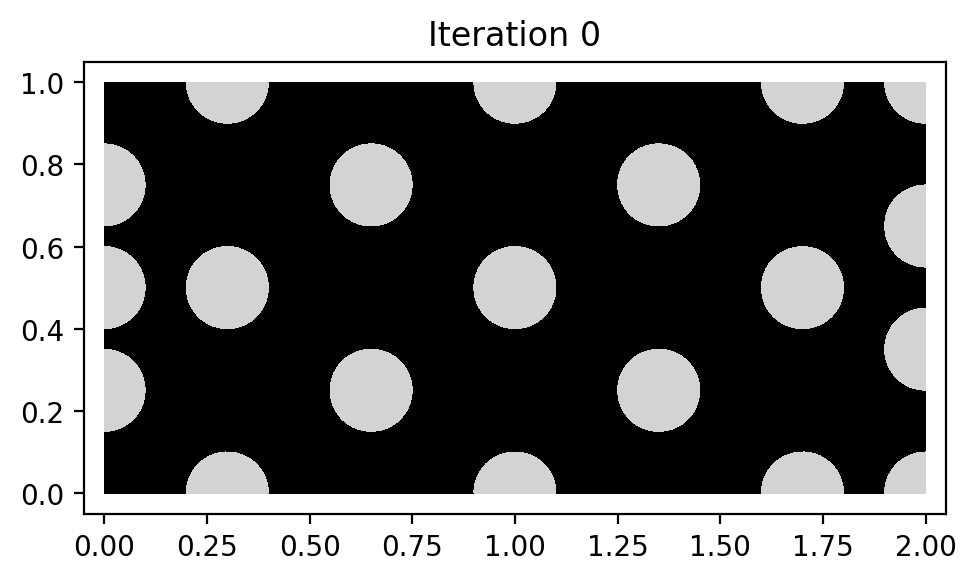

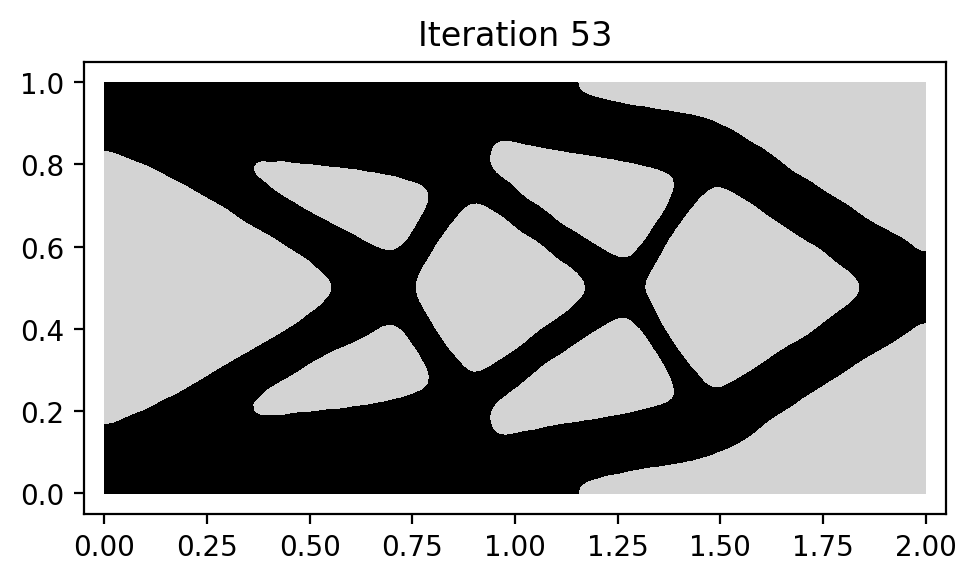

In [13]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t01/results.h5", size = (6, 3))

## Cantilever with two loads

In order to consider the compliance minimization problem with multiple forces, we write the class `CompliancePlus(Model)` with the following methods:

* The method `pde(self, phi)` models the weak formulation of linear elasticity equations for each force $g_i$: Find $u \in  H^1_{\Gamma_0}(\mathcal{D})^d$ such that
    $$
        \int_{\mathcal{D}} A_{\Omega}\sigma(u):\epsilon(v) = \int_{\Gamma_i} g_i \cdot v
        \qquad
        \forall \, v \in  H^1_{\Gamma_0}(\mathcal{D})^d
    $$
    for each $i$. We must write each weak formulation in the form $W_i(u, v) = 0$. Then, a list with components of the form `(W_i, bc_i)` must be returned by `pde`, where each `(W_i, bc_i)` contains a weak formulation and its corresponding boundary condition:

    ```python
    u = TrialFunction(self.space)
    v = TestFunction(self.space)
    su = self.sigma(u)
    ev = self.epsilon(v)

    pdes = []
    for g, ds_g in zip(self.g, self.ds_g):
        W = self.A(phi)*inner(su, ev)*self.dx - dot(g, v)*ds_g
        pdes.append((W, self.bc))
    ```

    In this case, we consider the same boundary condition `self.bc` for all problems, but the force `g` and the boundary `self.ds_g` where it are applied is different for each problem. Note that we have used  the same trial and test function for all weak formulations. This is because the above is just a symbolic representation. After the `for` iterations, the list `pdes` must be returned.


* The method `cost(self, phi, U)` must return the sum of all compliances:
    
    $$
        J(\Omega) = \sum_{i} \int_{\mathcal{D}} A_{\Omega}\sigma(u_i):\epsilon(u_i)
    $$

    Since the components of `U` represent the solution to the problems, we iterate on `U` to build the compliances:

    ```python
    J = []
    for u in U:	
        su = self.sigma(u)
        eu = self.epsilon(u)
        J.append(self.A(phi)*inner(su, eu)*self.dx)
    ``` 

    Then we return the sum of the components of the list `J`.

* The method `constraint(self, phi, U)` models the volume constraint function
    $$
        C(\Omega) = \frac{1}{V} \int_{\mathcal{D}} \chi_{\Omega}
    $$

* The method `derivative(self, phi, U, P)` returns the distributed shape derivatives corresponding to the cost and constraint functions:
    $$
        \begin{aligned}
            S_0 &= \vec{0} \\
            S_1 &= \sum_{i=1}^{2} A_{\Omega} (2{Du_i}^{\top}\sigma(u_i)- \sigma(u_i):e(u_i))I
        \end{aligned}
    $$
    $$
        \begin{aligned}
            S_0 &= \vec{0} \\
            S_1 &= \frac{1}{V} \chi_{\Omega} I
        \end{aligned}
    $$

* The method `bilinear_form(self, th, xi)` is the same as the previous example.

In [6]:
!mpirun -np 2 python test.py 04 > ../results/t04/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


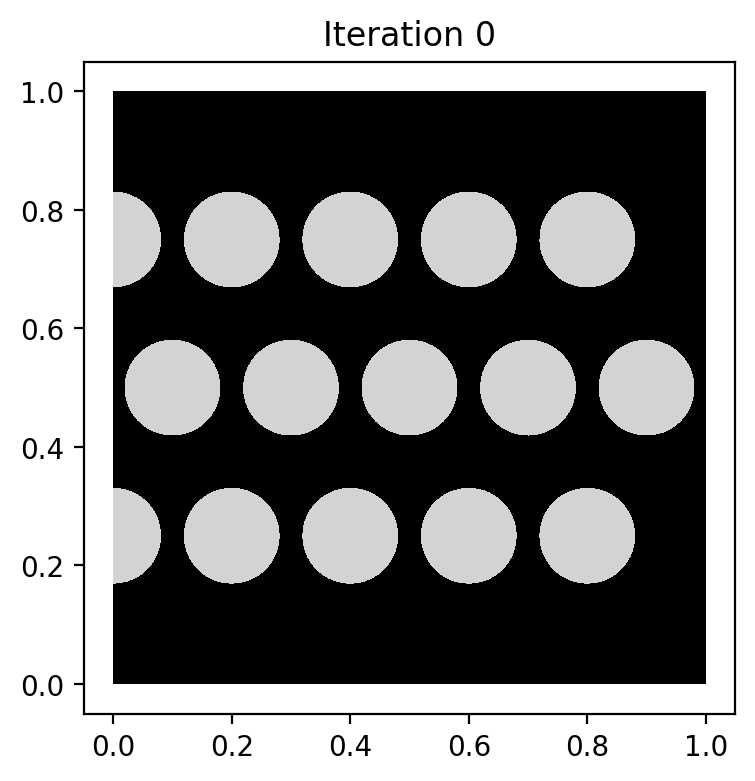

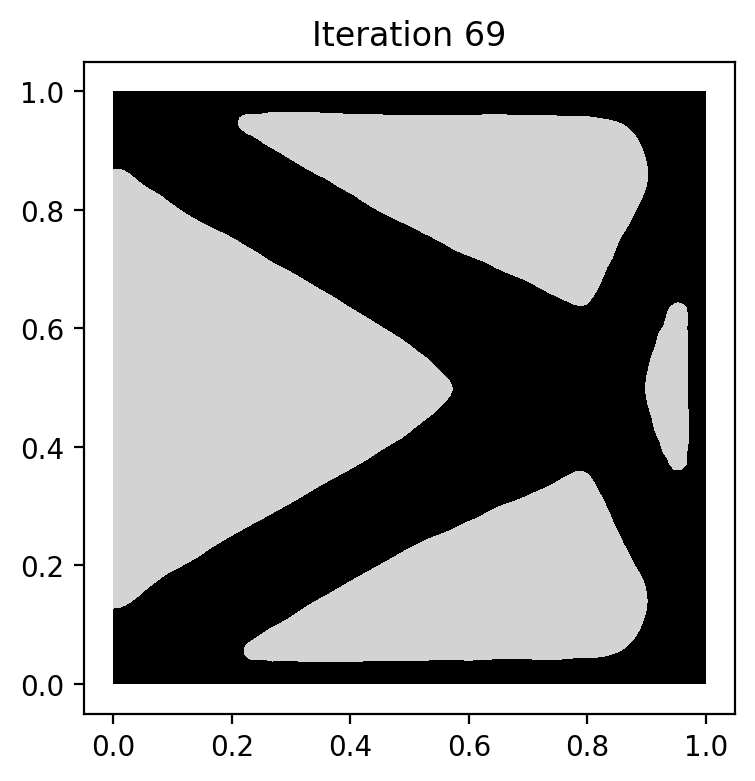

In [7]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial

plot_tutorial("../results/t04/results.h5", (4, 4))

In [8]:
!mpirun -np 2 python test.py 18 > ../results/t18/out.txt

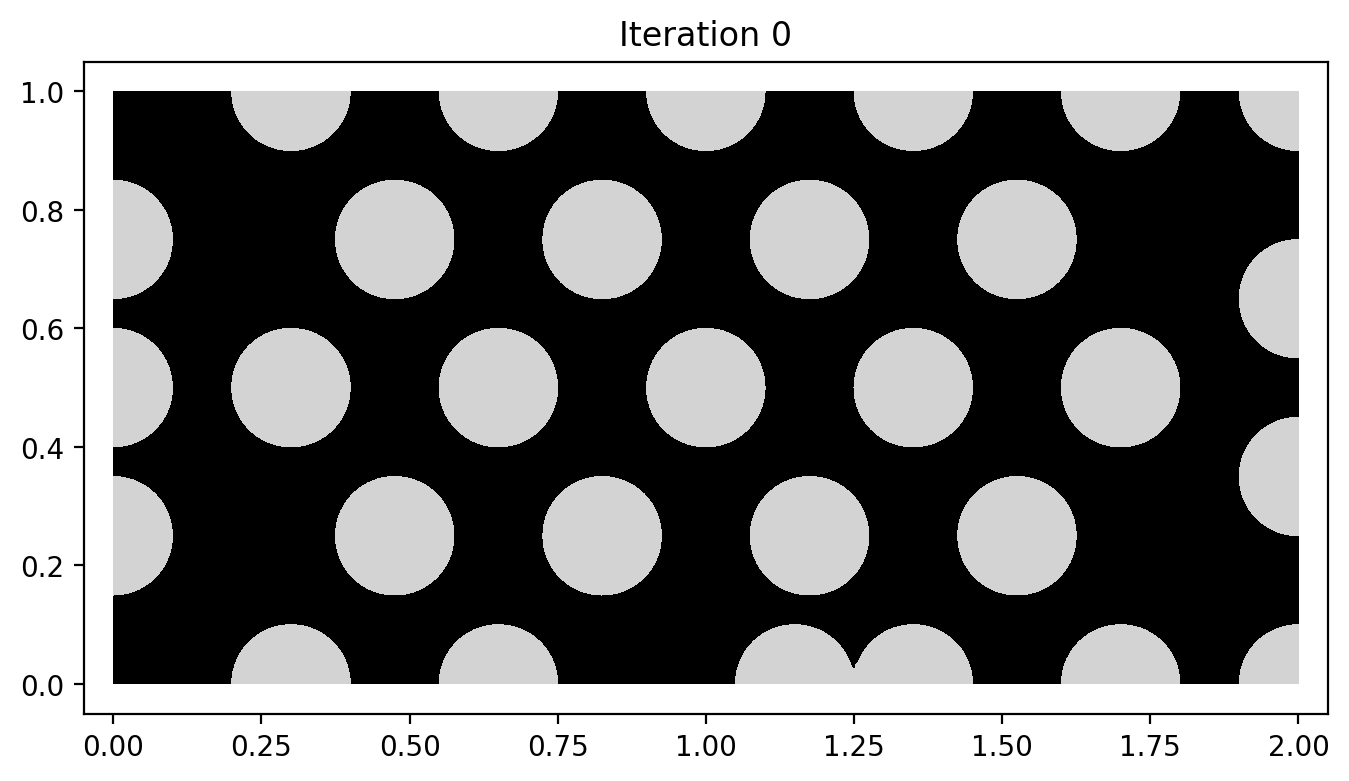

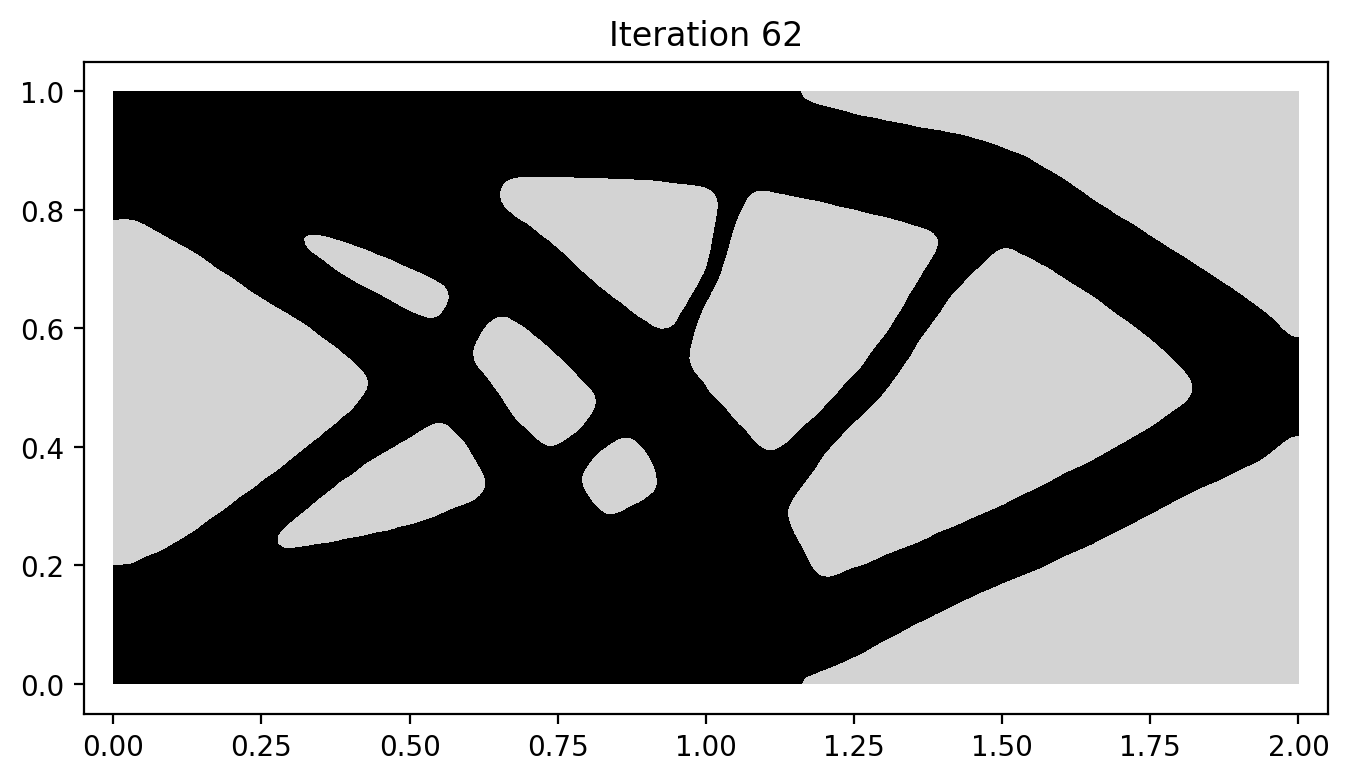

In [9]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial

plot_tutorial("../results/t18/results.h5", (8, 4))

# Inverse Problem in Linear Elasticity

We address the inverse problem of reconstructing an internal object within an elastic body from known applied forces and the corresponding displacements measured on the boundary.

Let $\Gamma_0$ and $\Gamma_1$ be subsets of $\Gamma$.
The inverse problem can be formulated as follows:
$$
\min_{\Omega \subset \mathcal{D}}
\;
\frac{\alpha}{2}\int_{\mathcal{D}}\left|u-v\right|^{2} + 
\frac{\beta}{2}\int_{\Gamma_{1}}\left|u-v\right|^{2}
$$
where $u$ and $v$ are the solutions to
$$
\begin{array}{rcl}
    -\mathrm{div} A_{\Omega} \sigma(u) = 0 & \text{in} & \mathcal{D} \\
                                     u = 0 & \text{on} & \Gamma_{0} \\
                 A_{\Omega} \sigma(u)n = f & \text{on} & \Gamma_{1}                     
\end{array}
$$
and
$$
\begin{array}{rcl}
    -\mathrm{div} A_{\Omega} \sigma(v) = 0 & \text{in} & \mathcal{D} \\
                                     v = 0 & \text{on} & \Gamma_{0} \\
                                     v = g & \text{on} & \Gamma_{1}    
\end{array}
$$
respectively. 
We use $A_{\Omega} = 10\chi_{\Omega} + \chi_{\overline{\mathcal{D}}\setminus\Omega}$.
The constants $\alpha$ and $\beta$ represent weights.



To address this problem, the `InverseElasticity(Model)` class is constructed with the following methods:

* Two methods are written to model each partial differential equation. In `f_prob(self, ...)` is written the weak formulation of the $f$-problem: Find $u \in  H^1_{\Gamma_0}(\mathcal{D})^d$ such that
	$$
		\int_{\mathcal{D}} A_{\Omega}\sigma(u):\epsilon(w) =
		\int_{\Gamma_1} f \cdot w
		\qquad
		\forall \, w \in  H^1_{\Gamma_0}(\mathcal{D})^d
	$$
    Before write the $g$-problem, $g$ is extended to the whole domain, and the $g$-problem is rewritten in such a way that we seek a solution in $H^1_{\Gamma_0}(\mathcal{D})^d$. Thus, in `g_prob(self, ...)` is written the following weak formulation: Find $v \in  H^1_{\Gamma_0}(\mathcal{D})^d$ such that
    $$
		\int_{\mathcal{D}} A_{\Omega}\sigma(v):\epsilon(w) =
		- \int_{\mathcal{D}} A_{\Omega}\sigma(g):\epsilon(w)
		\qquad
		\forall \, w \in  H^1_{\Gamma_0}(\mathcal{D})^d
	$$
    Note that $v+g$ is the solution of the original $g$-problem. The extension of $g$ will be discussed later. Both weak formulations are collected in the method `pde(self, phi)`. Recall that only the method `pde` is required, while `f_prob` and `g_prob` help us to write cleaner code.

* The cost functional becomes
    $$
		J(\Omega) = \frac{\alpha}{2}\int_{\mathcal{D}}\left|u-v-g\right|^{2} +
		\frac{\beta}{2}\int_{\Gamma_{1}}\left|u-g\right|^{2}
	$$
    The method `cost(self, phi, U)` returns $J(\Omega)$.

* The method `constraint(self, phi, U)` is empty for this problem.

* The method `adjoint(self, phi, U)` collect the outputs of the methods `adj_f_prob(self, ...)` and `adj_g_prob(self, ...)`, which contain the adjoints of the $f$-problem and $g$-problem, respectively. Namely, the adjoints problems are the following: Find $p \in  H^1_{\Gamma_0}(\mathcal{D}, \mathbb{R}^d)$ such that
	$$
		\int_{\mathcal{D}} A_{\Omega}\sigma(p):e(r) =
		-\alpha \int_{\mathcal{D}} (u-v-g) \cdot r
		-\beta \int_{\Gamma_1} (u - g) \cdot r
		\qquad
		\forall \, r \in  H^1_{\Gamma_0}(\mathcal{D})^d
	$$
    Find $q \in  H^1_0(\mathcal{D}, \mathbb{R}^d)$ such that
	$$
		\int_{\mathcal{D}} A_{\Omega}\sigma(q):e(r) =
		\alpha \int_{\mathcal{D}} (u-v-g) \cdot r
		\qquad
		\forall \, r \in  H^1_0(\mathcal{D})^d
	$$

* The method `derivative(self, phi, U, P)` returns the components $S_0$ and $S_1$ of the distributed shape derivative of the cost functional:
    $$
        \begin{aligned}
            S_0 &= -\alpha{Dg}^{\top}(u-v-g) +
			A_{\Omega}\sum_{i,j=1}^{d}{\sigma (q)}_{i,j}\nabla(e(g)_{i,j}) \\
            S_1 &= \left(\frac{\alpha}{2}{|u-v-g|}^2 + A_{\Omega}\sigma(u):e(p) + A_{\Omega}\sigma(v+g):e(q)\right)I\\
			{} & 
			\quad + A_{\Omega}\left({Du}^{\top}\sigma(p) + {Dp}^{\top}\sigma(u) + {Dv}^{\top}\sigma(q) + {Dq}^{\top}\sigma(v+g)\right)
        \end{aligned}
    $$

* The method `bilinear_form(self, th, xi)` contains the bilinear form to be used to calculate the vector field $\theta$, namely
	$$
		B(\theta, \xi) =  {10}^{-1}\int_{\mathcal{D}} \theta \cdot \xi + 
							\int_{\mathcal{D}} D\theta : D\xi
	$$
	with $\theta, \xi \in H^1_{0}(\mathcal{D}, \mathbb{R}^d)$

**Remark.** The Lagrangian functional for this problem is given by
$$
\begin{aligned}
    \mathcal{L}(\Omega,\varphi, \psi, \rho, \varrho) & = 
	\frac{\alpha}{2}\int_{\mathcal{D}}\left|\varphi-\psi-g\right|^{2} +
    \frac{\beta}{2}\int_{\Gamma_{1}}\left|\varphi-g\right|^{2}  \\
    & +\int_{\mathcal{D}}A_{\Omega}\sigma(\varphi):\epsilon(\rho) - \int_{\Gamma_{1}}f \cdot \rho\\
    & +\int_{\mathcal{D}}A_{\Omega}\sigma(\psi):\epsilon(\varrho) + \int_{\mathcal{D}}A_{\Omega}\sigma(g):\epsilon(\varrho)
\end{aligned}
$$

In [1]:
!mpirun -np 3 python test.py 06 > ../results/t06/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0
X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


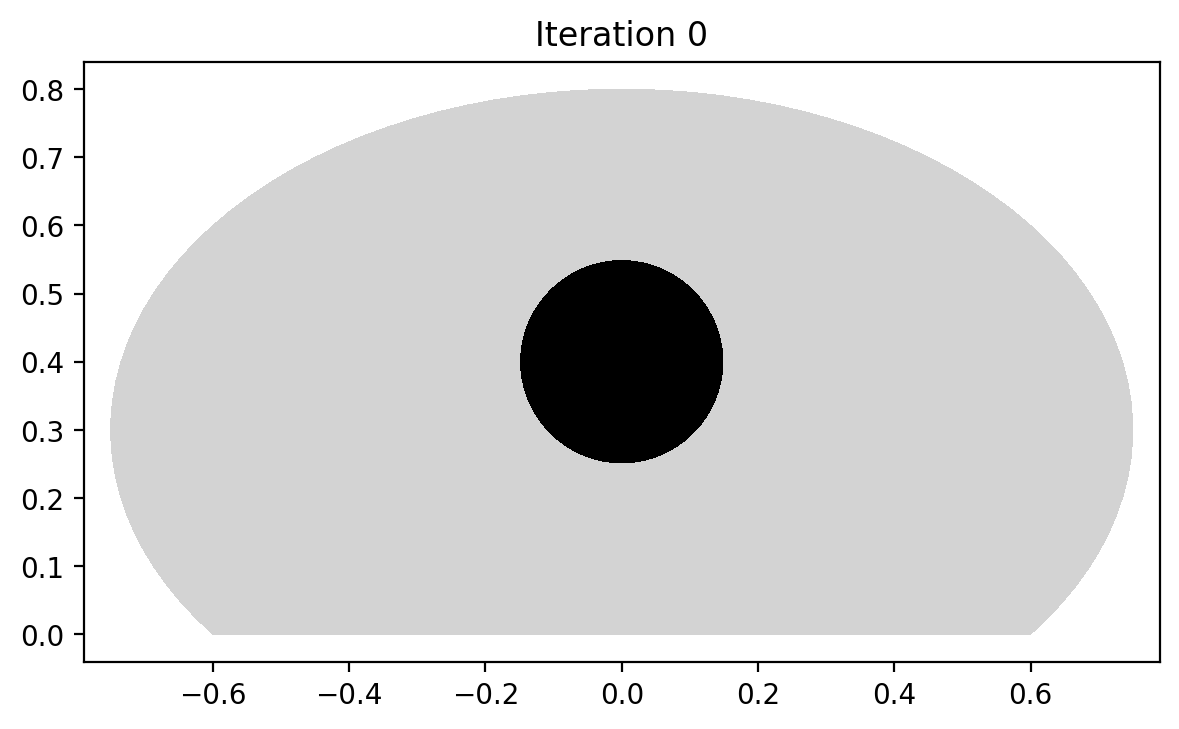

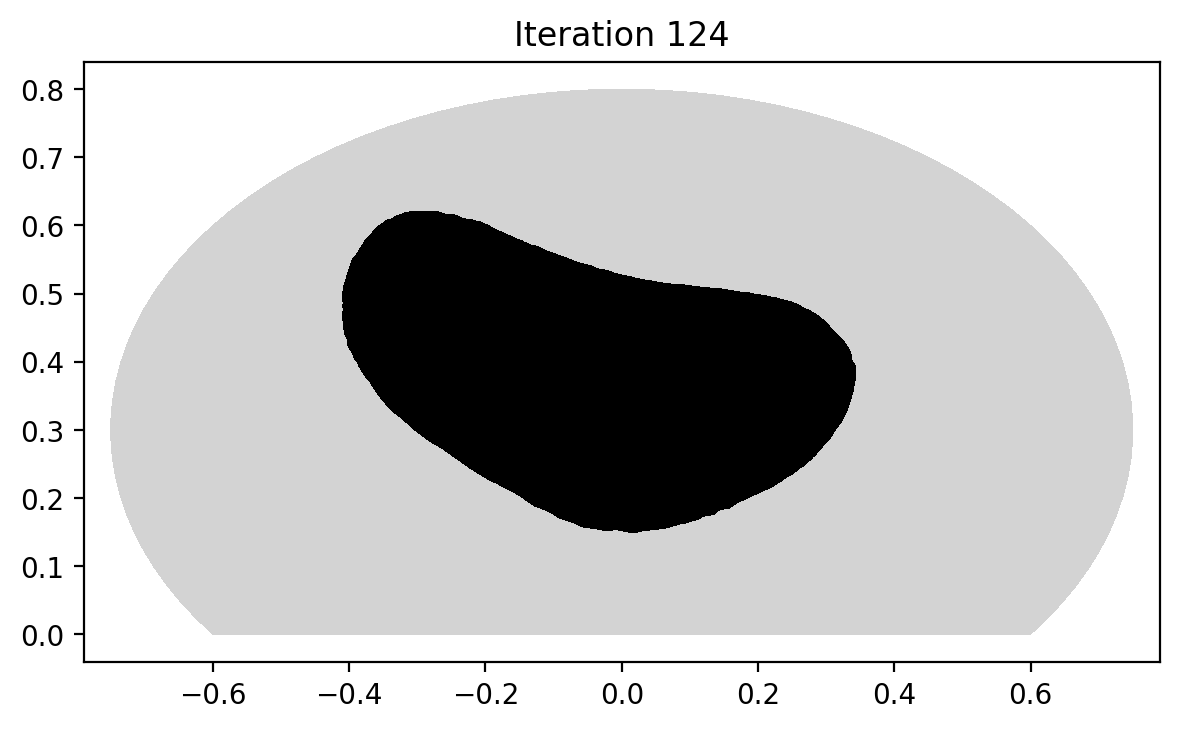

In [2]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial

plot_tutorial("../results/t06/results.h5", (6, 4))

In [8]:
!mpirun -np 12 python test.py 08 > ../results/t08/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0
X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


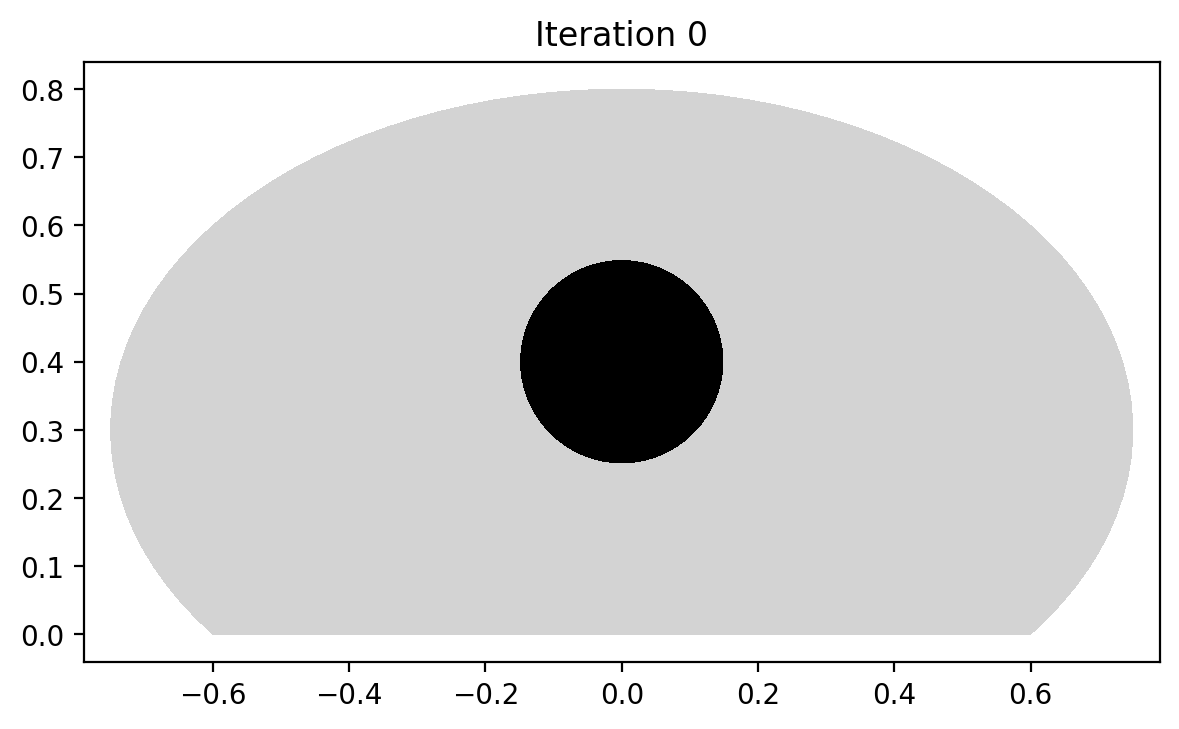

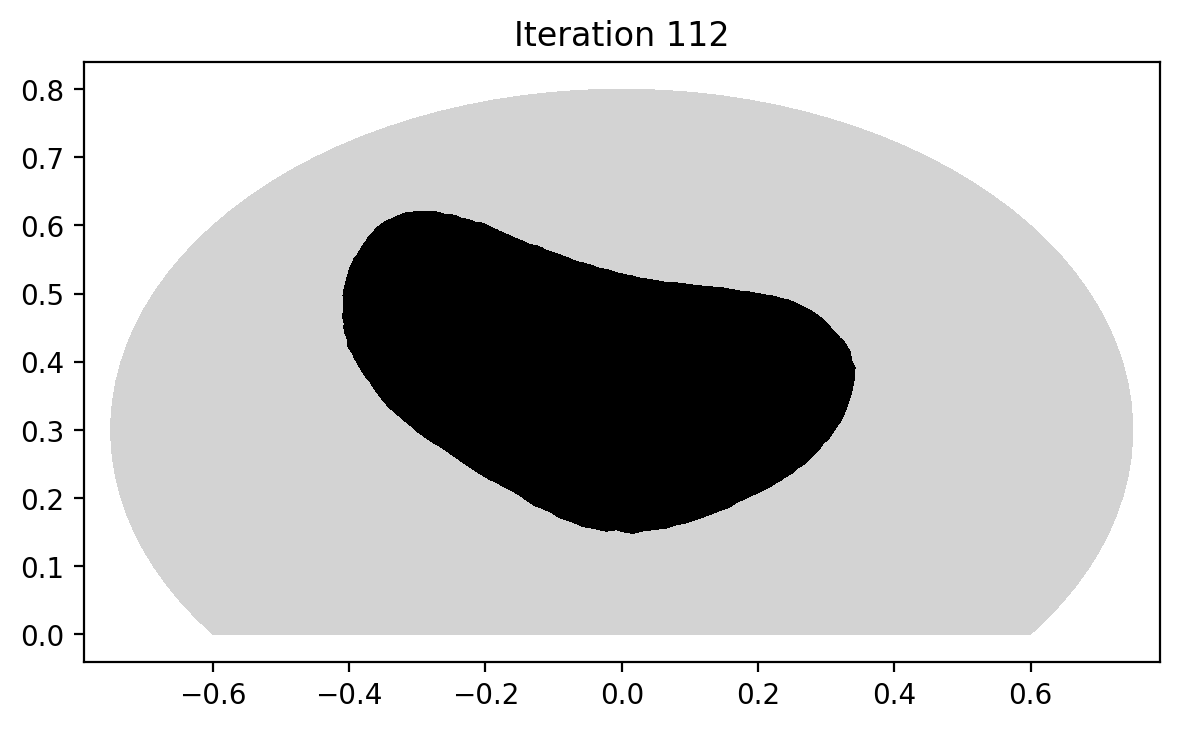

In [10]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial

plot_tutorial("../results/t08/results.h5", (6, 4))

# Steady-state heat conduction

The problem reads
$$
\min_{\Omega \subset \mathcal{D}} \int_{\mathcal{D}} A_{\Omega}\left|\nabla u\right|^{2}
\quad\text{subject to}\quad
\int_{\mathcal{D}} \chi_{\Omega} = V
$$
where $u$ is the solution to
$$
\begin{array}{rlcc}
    -\mathrm{div}(A_{\Omega} \nabla u) & = f & \text{in} & \mathcal{D}\\
                                     u & = 0 & \text{on} & \Gamma_{0}\\
                        \partial_{n} u & = 0 & \text{on} & \Gamma_{1}
\end{array}
$$

and $A_{\Omega} = \chi_{\Omega} + {10}^{-3}\chi_{\mathcal{D}\backslash\Omega}$.

* `pde(self, phi)` Find $u \in  H^1_{\Gamma_0}(\mathcal{D})$ such that
	$$
		\int_{\mathcal{D}} A_{\Omega} \nabla u \cdot \nabla v = 
		\int_{\mathcal{D}} f v
		\qquad
		\forall \, v \in  H^1_{\Gamma_0}(\mathcal{D})
	$$


In [1]:
!mpirun -np 2 python test.py 09 > ../results/t09/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


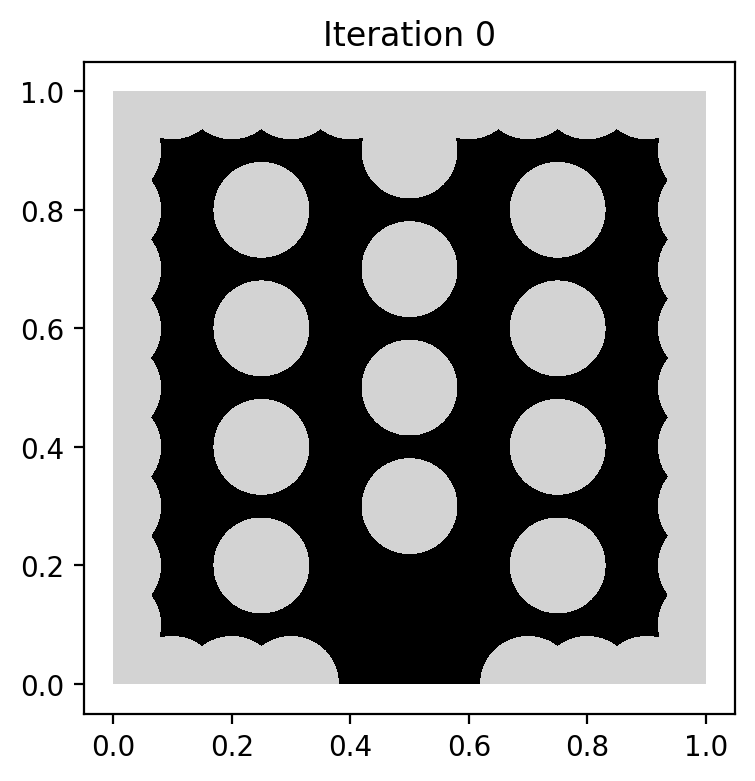

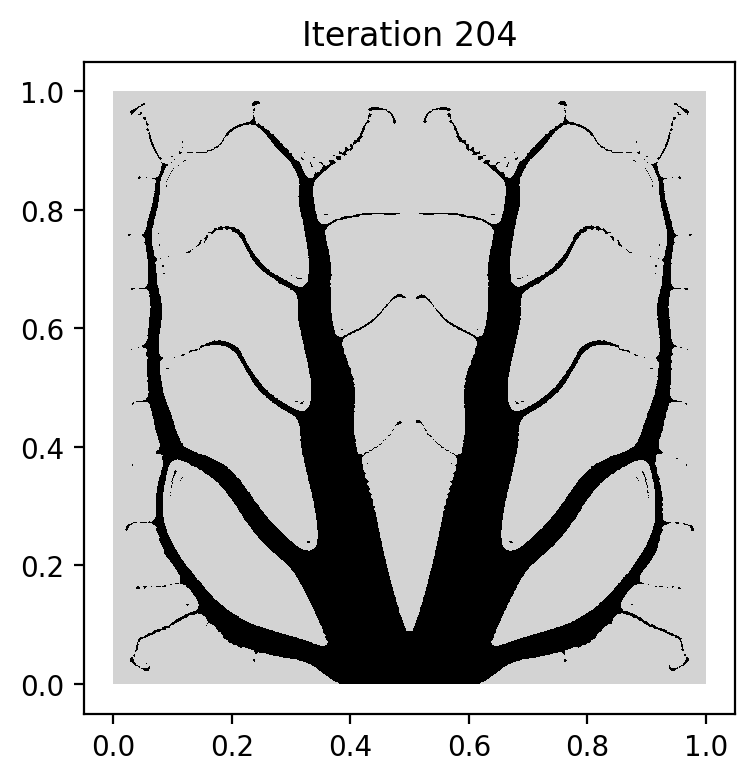

In [2]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t09/results.h5", size = (4, 4))

In [1]:
!mpirun -np 2 python test.py 10 > ../results/t10/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


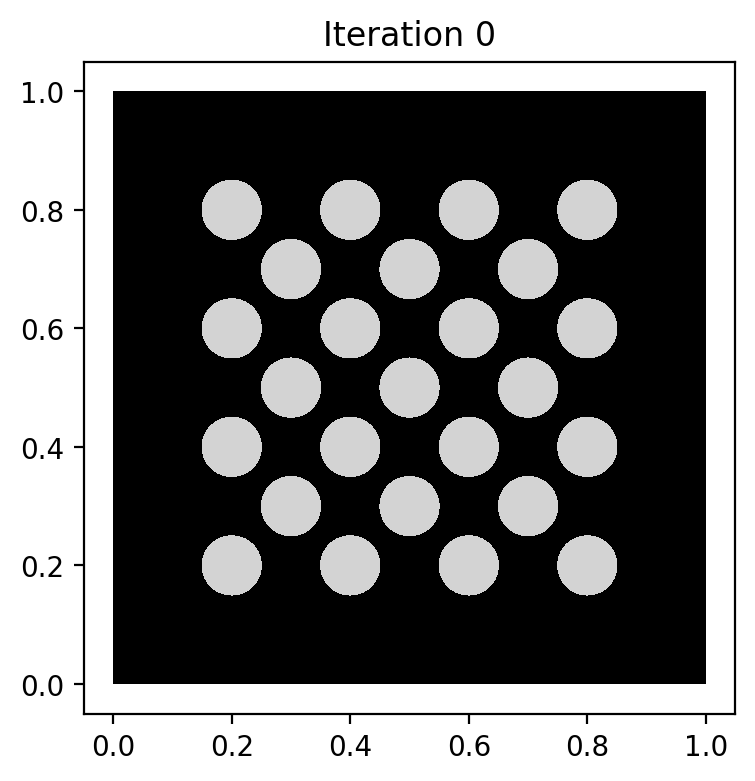

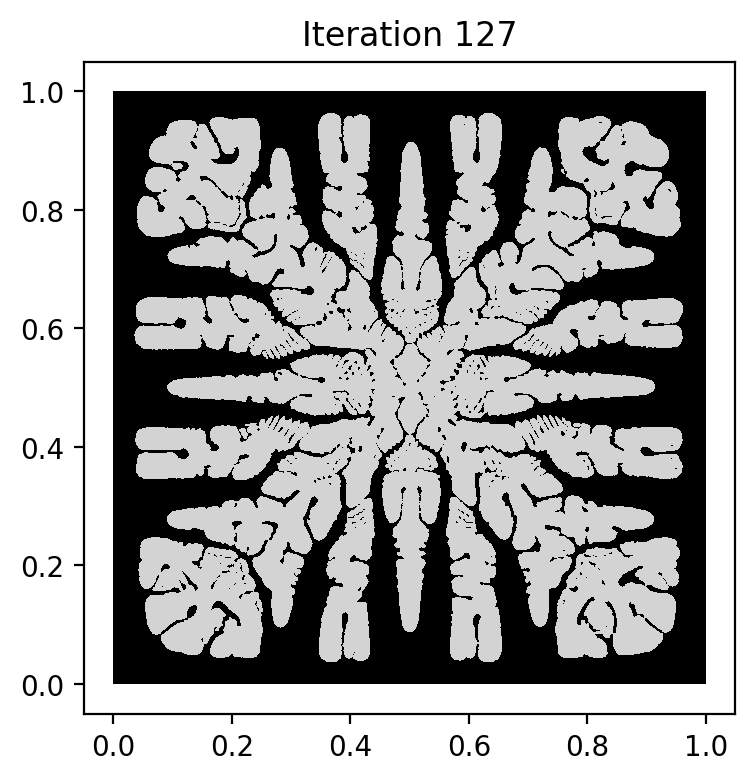

In [2]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t10/results.h5", size = (4, 4))

In [10]:
!mpirun -np 2 python test.py 13 > ../results/t13/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


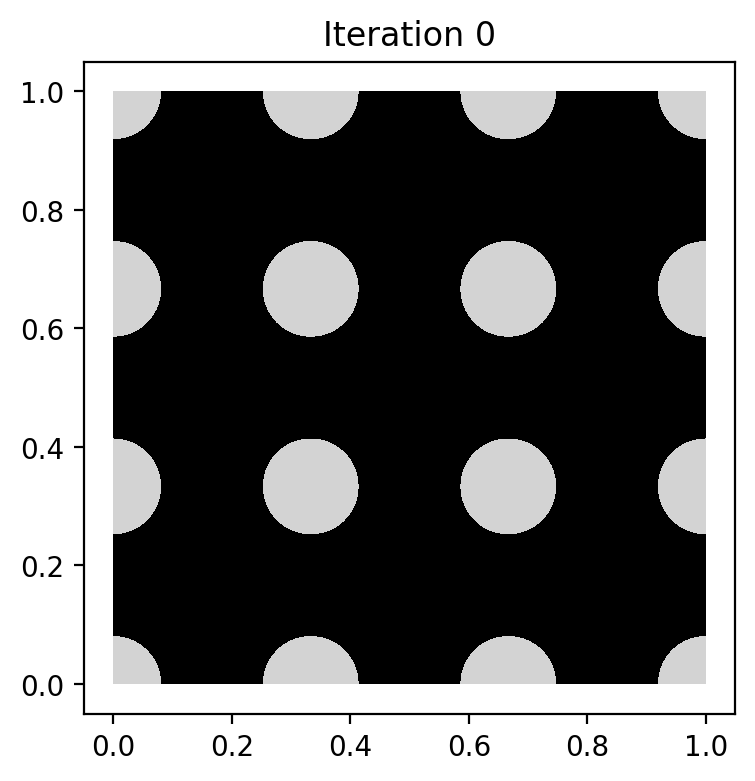

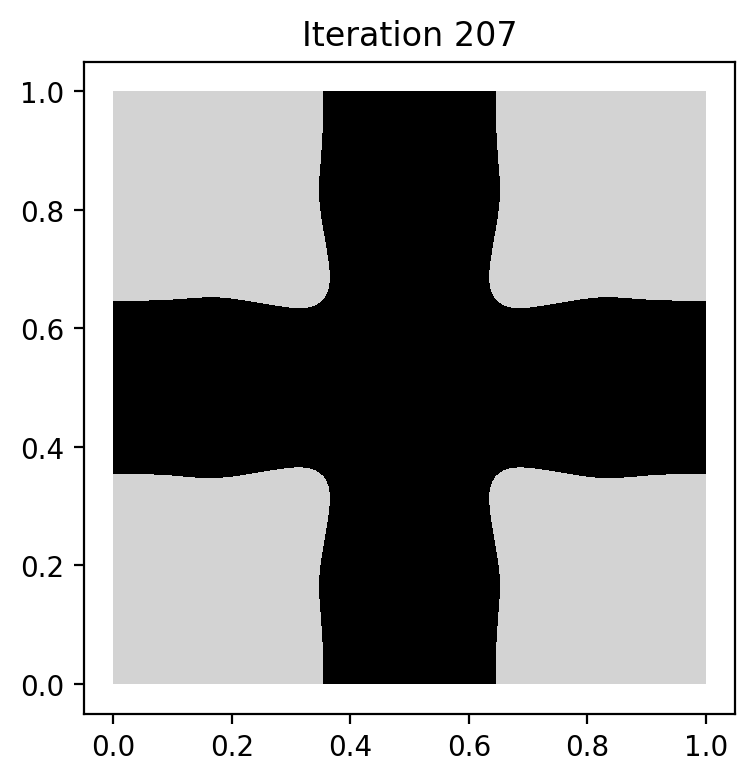

In [11]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t13/results.h5", size = (4, 4))

In [1]:
!mpirun -np 2 python test.py 12 > ../results/t12/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


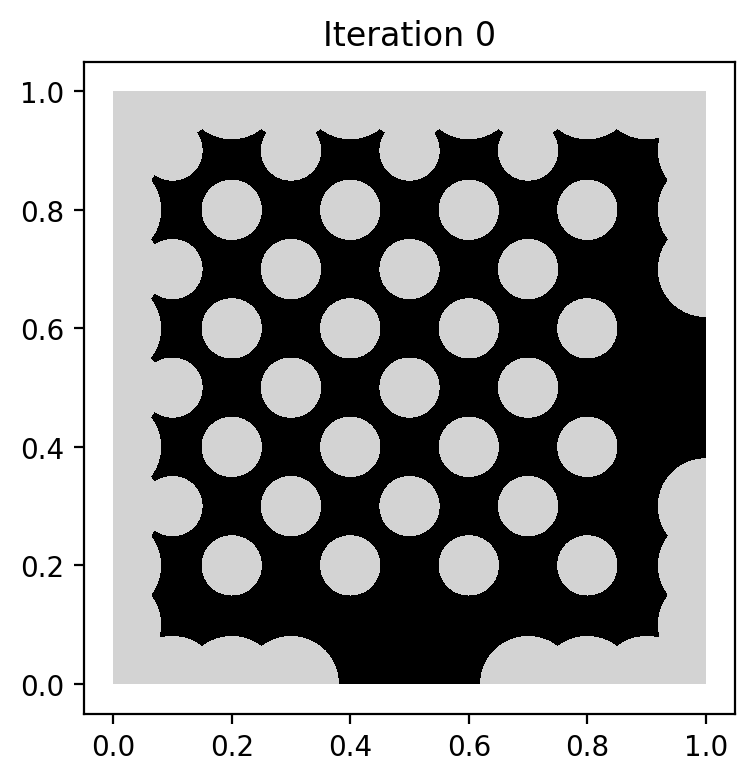

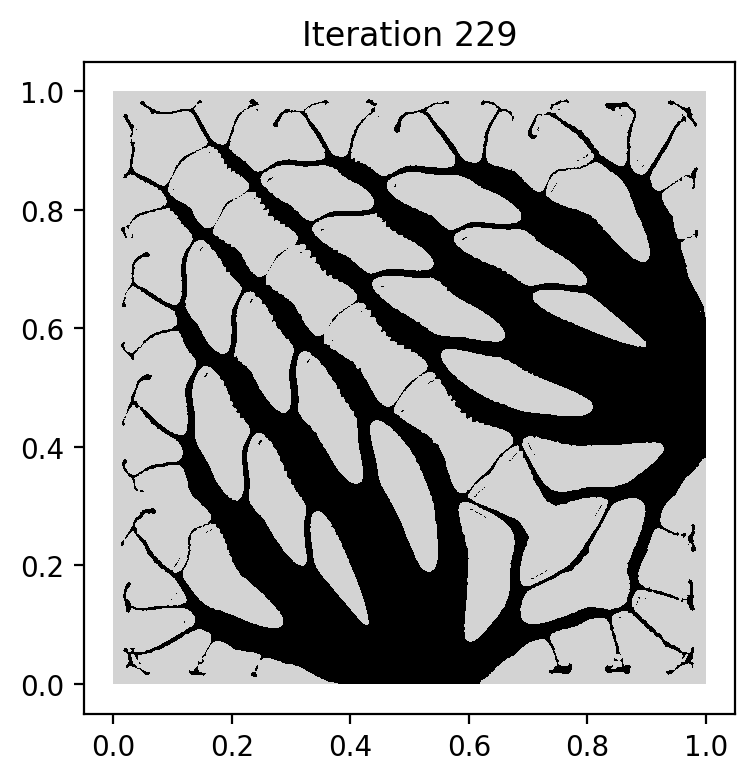

In [5]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t12/results.h5", size = (4, 4))

In [3]:
!mpirun -np 2 python test.py 13 > ../results/t13/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


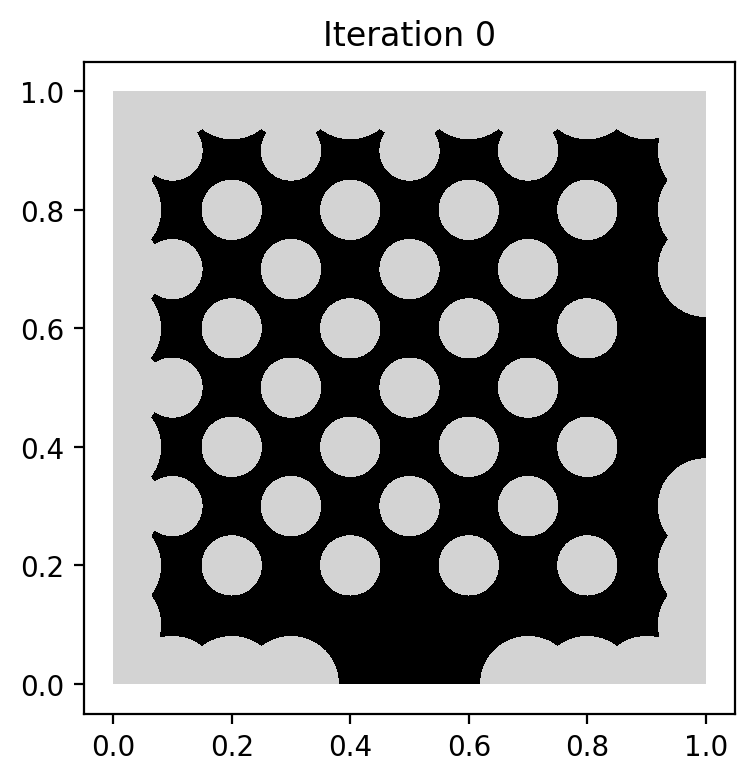

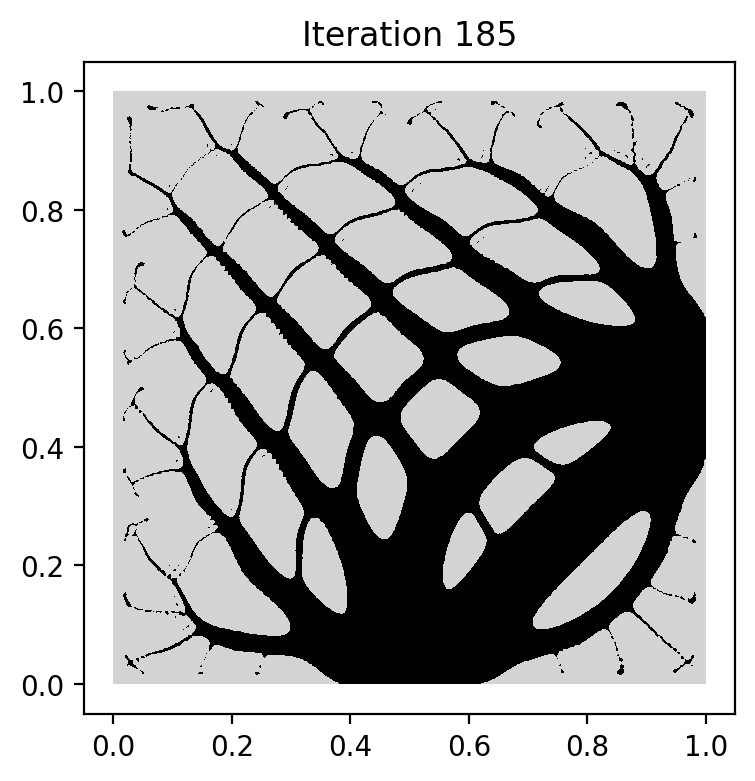

In [4]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t13/results.h5", size = (4, 4))

In [6]:
import numpy as np
from plots import plot_lag2
datat12 = np.load("../results/t12/data.npz")["Lg"]
datat13 = np.load("../results/t13/data.npz")["Lg"]
#plot_lag2(datat13, "Multiple", datat12, "Simple", figsize = (4.2,4))
plot_lag2(datat13, "Multiple", datat12, "Simple", figsize = (4.0,4), filename = "../tex/heat4_0.png")

# Population dynamics

The problem reads
$$
\max_{\Omega \subset \mathcal{D}} \int_{\mathcal{D}} u
\quad\text{subject to}\quad
\int_{\mathcal{D}} \chi_{\Omega} = V
$$
where $u$ is the solution to
$$
\begin{aligned}
-\nabla^2 u  &= r u\left(1 - \frac{u}{K_{\Omega}}\right) && \text{in} \quad \mathcal{D} \\
\partial_{n} u &= 0                                        && \text{on} \quad \Gamma
\end{aligned}
$$
with $K_{\Omega}:\mathcal{D} \rightarrow \mathbb{R}$ defined by
$K_{\Omega} = \chi_{\Omega} + {10}^{-2}\chi_{\mathcal{D}\backslash\Omega}$. Here, $u$ represents the population size, $r$ is a positive constant that represents the growth rate of the population, and the positive function $K_{\Omega}$ represents the carrying capacity of the environment.

* `pde(self, phi)`
    $$
    \int_{\mathcal{D}}\nabla u \cdot \nabla v =
    \int_{\mathcal{D}}ru\left(1-\frac{u}{K_{\Omega}}\right)v
    \qquad
    \forall \, v \in  H^1(\mathcal{D})
    $$


* `cost(self, phi, U)`
    $$
        J(\Omega) = -\int_{\mathcal{D}}u
    $$
    Lagrangian functional
    $$
    L(\Omega, \varphi, \rho )=
    - \int_{\mathcal{D}} \varphi +
    \int_{\mathcal{D}}D \nabla\varphi\cdot\nabla\rho -
    \int_{\mathcal{D}}r\varphi\left(1-\frac{\varphi}{K_{\Omega}}\right)\rho
    $$

* `adjoint(self, phi, U)`
    $$
    \int_{\mathcal{D}}\nabla p \cdot \nabla q +
    \int_{\mathcal{D}}r\left(\frac{2u}{K_{\Omega}}-1\right)pq = 
    \int_{\mathcal{D}}q
    \qquad
    \forall \, q \in  H^1(\mathcal{D})
    $$

* `constraint(self, phi, U)`
    
    $$
        C(\Omega) = \frac{1}{V} \int_{\mathcal{D}} K_{\Omega}
    $$

* Derivatives.
    $$
    S^J_0 = \boldsymbol{0}, \quad S^J_1 = \left(
                \nabla u\cdot\nabla p-u-ru\left(1-\frac{u}{K_{\Omega}}\right)p
        \right)I-
        \left(\nabla u\otimes\nabla p+\nabla p\otimes\nabla u\right)
    $$
    $$
    S_0^C = \boldsymbol{0}, \quad S_1^C = \frac{1}{V} \chi_{\Omega}I.
    $$

We perform test with growth rates $r = 10, 40$ and $100$.

In [1]:
!mpirun -np 2 python test.py 14 > ../results/t14/out.txt

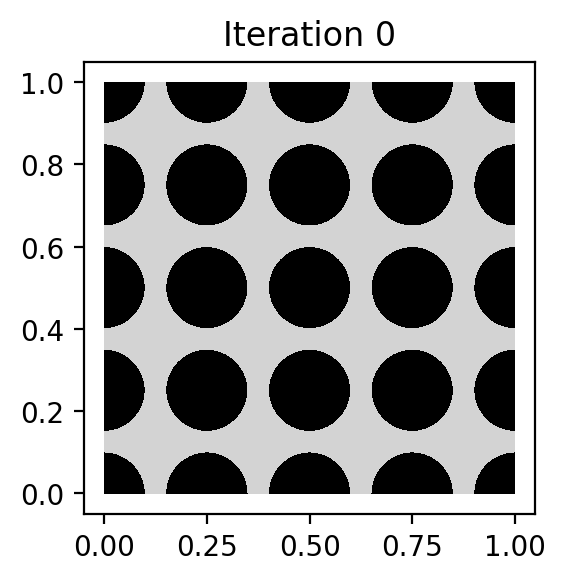

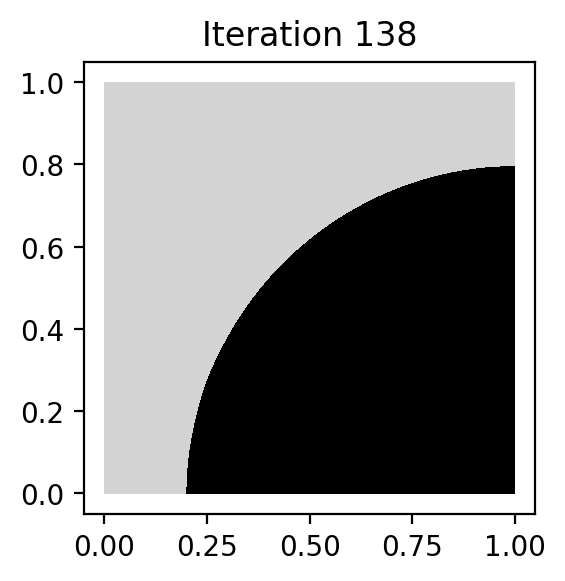

In [11]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t14/results.h5", size = (3, 3))

In [4]:
!mpirun -np 2 python test.py 15 > ../results/t15/out.txt

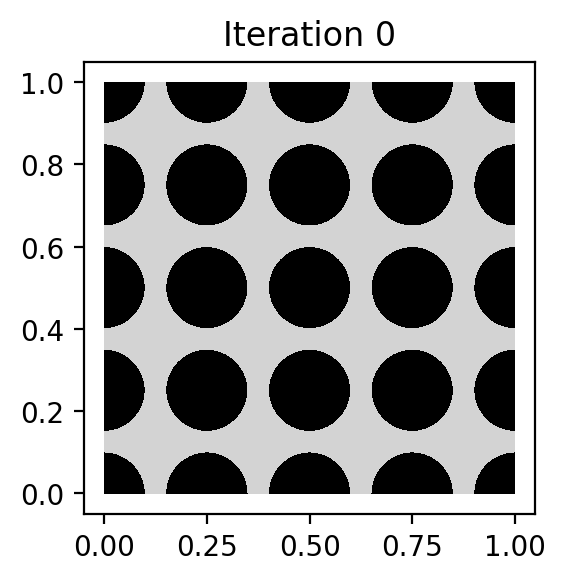

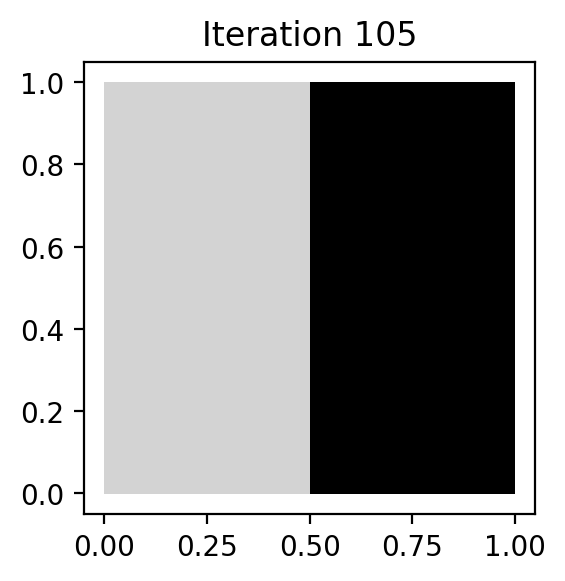

In [13]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t15/results.h5", size = (3, 3))

In [7]:
!mpirun -np 2 python test.py 16 > ../results/t16/out.txt

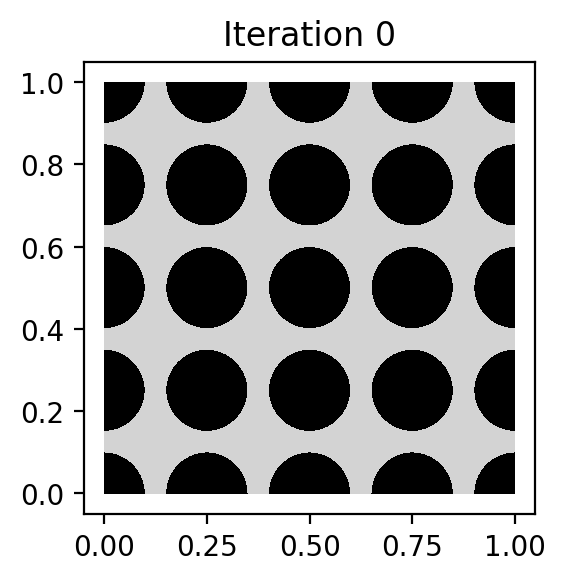

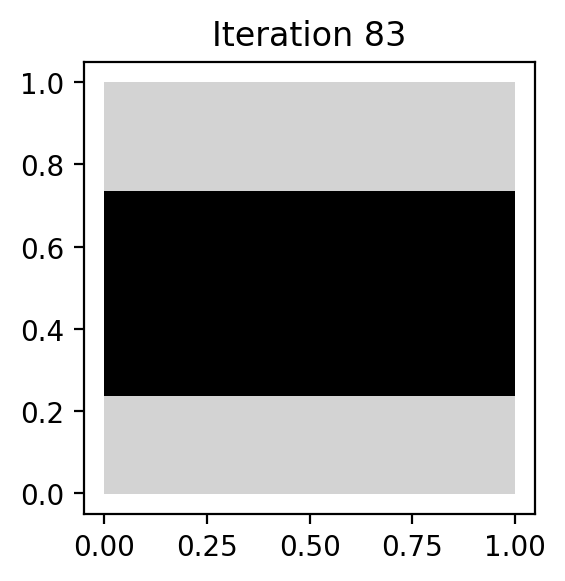

In [15]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t16/results.h5", size = (3, 3))